# Semana 2: Costo de capital y tasa de descuento · Práctica

**Tópicos de Finanzas Avanzadas (ECON-421, UPAO 2026-20)** · CFA · Corporate Issuers: *Cost of Capital, Advanced Topics* · Equity: *Return Concepts*

**Hoy estimamos el costo de capital completo de Southern Copper (SCCO):**
1. Beta por regresión MCO con `statsmodels` (y su error de estimación).
2. Beta ajustado de Blume; desapalancar y reapalancar.
3. Costo del equity por CAPM con insumos declarados.
4. WACC con datos reales de `yfinance`.
5. Nuevas funciones para `utils/finanzas.py`: `capm()`, `wacc()`, `beta_desapalancar()`, `beta_reapalancar()`.

> Regla de la semana 1 que sigue vigente: todo dato entra por API y todo supuesto se declara en su celda.

## 1. Beta por regresión

El beta no se observa, se estima. El estándar del mercado: 5 años de retornos mensuales contra un índice amplio.

$$r_{i,t} = \alpha + \beta \, r_{m,t} + \varepsilon_t$$

In [5]:
pip install statsmodels

  Using cached statsmodels-0.15.0-cp314-cp314-win_amd64.whl.metadata (9.6 kB)
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached patsy-1.0.3-py2.py3-none-any.whl.metadata (3.7 kB)
  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
Using cached statsmodels-0.15.0-cp314-cp314-win_amd64.whl (11.3 MB)
Using cached formulaic-1.2.2-py3-none-any.whl (118 kB)
Using cached interface_meta-2.0.1-py3-none-any.whl (15 kB)
Using cached patsy-1.0.3-py2.py3-none-any.whl (233 kB)
Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl (37.4 MB)

   ---------------------------------------- 0/7 [wrapt]
   ---------------------------------------- 0/7 [wrapt]
   ---------------------------------------- 0/7 [wrapt]
   ----- ---------------------------------- 1/7 [scipy]
   ----- ---------------------------------- 1/7 [scipy]
   ----- ---------------------------------- 1/7 [scipy]
   ----- ---

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

px = yf.download(["SCCO", "^GSPC"], start="2021-08-01",
                 interval="1mo", auto_adjust=True, progress=False)["Close"]
r = px.pct_change().dropna()
r = r.rename(columns={"^GSPC": "SP500"})
r.tail()

Ticker,SCCO,SP500
Date,,
2026-05-01,0.131259,0.051470
2026-06-01,-0.089075,-0.010646
2026-07-01,0.048491,-0.001285
2026-08-01,0.163291,0.026225
2026-09-01,0.001867,-0.006477


In [5]:
px

Ticker,SCCO,^GSPC
Date,,
2021-08-01,47.940598,4522.680176
2021-09-01,43.000233,4307.540039
2021-10-01,45.949135,4605.379883
2021-11-01,45.544838,4567.000000
2021-12-01,48.043964,4766.180176
...,...,...
2026-05-01,187.992462,7580.060059
2026-06-01,171.247101,7499.359863
2026-07-01,179.550980,7489.720215


In [6]:
r

Ticker,SCCO,SP500
Date,,
2021-09-01,-0.103052,-0.047569
2021-10-01,0.068579,0.069144
2021-11-01,-0.008799,-0.008334
2021-12-01,0.054872,0.043613
2022-01-01,0.035327,-0.052585
...,...,...
2026-05-01,0.131259,0.051470
2026-06-01,-0.089075,-0.010646
2026-07-01,0.048491,-0.001285


In [ ]:
X = sm.add_constant(r["SP500"])
modelo = sm.OLS(r["SCCO"], X, missing="drop").fit()
print(modelo.summary())

beta_ols = modelo.params["SP500"] 
ee = modelo.bse["SP500"]
print(f"\nBeta OLS = {beta_ols:.3f}  (error estándar {ee:.3f})")
print(f"Intervalo aproximado al 95%: [{beta_ols - 2*ee:.2f}, {beta_ols + 2*ee:.2f}]")

                            OLS Regression Results                            
Dep. Variable:                   SCCO   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     14.21
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           0.000380
Time:                        20:15:54   Log-Likelihood:                 50.610
No. Observations:                  61   AIC:                            -97.22
Df Residuals:                      59   BIC:                            -93.00
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0199      0.014      1.414      0.1

**Lectura de la salida (estilo examen):** el beta es la pendiente; su error estándar mide cuánta confianza le tenemos;
el $R^2$ dice qué fracción del riesgo de SCCO es riesgo de mercado. Lo que el $R^2$ no explica es riesgo propio,
diversificable, y por eso el CAPM no lo remunera.

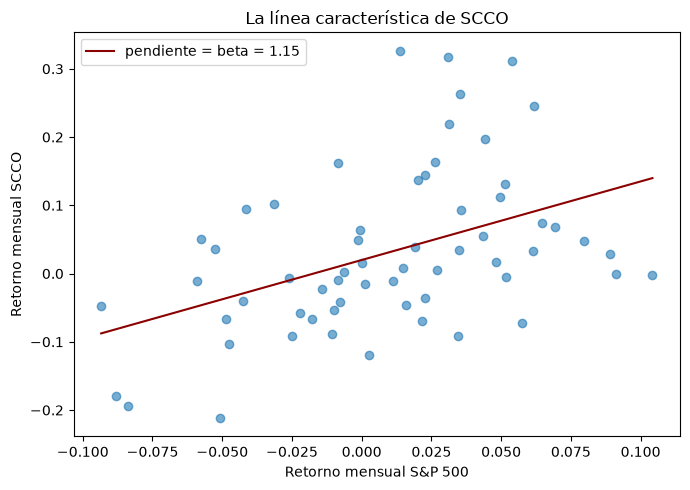

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(r["SP500"], r["SCCO"], alpha=0.6)
xs = np.linspace(r["SP500"].min(), r["SP500"].max(), 50)
ax.plot(xs, modelo.params["const"] + beta_ols * xs, color="darkred",
        label=f"pendiente = beta = {beta_ols:.2f}")
ax.set_xlabel("Retorno mensual S&P 500")
ax.set_ylabel("Retorno mensual SCCO")
ax.set_title("La línea característica de SCCO")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Beta ajustado y apalancamiento

Blume documentó que los betas tienden a 1 con el tiempo. El ajuste estándar:

$$\beta_{aj} = 0.67 \, \beta_{OLS} + 0.33$$

Y para transferir betas entre empresas con distinta deuda (ignorando el beta de la deuda):

$$\beta_U = \frac{\beta_E}{1 + (1-t)\,D/E} \qquad \beta_E = \beta_U \left[1 + (1-t)\,D/E\right]$$

In [15]:
def beta_desapalancar(beta_e, d_e, t):
    """Beta del negocio (unlevered) a partir del beta de equity."""
    return beta_e / (1 + (1 - t) * d_e)

In [16]:
b_u=beta_desapalancar(1.4, 0.8, 0.30)
print(b_u)

0.8974358974358974


In [15]:
def beta_reapalancar(beta_u, d_e, t):
    """Beta del equity para una estructura del capital objetivo."""
    return beta_u * (1 + (1 - t) * d_e)

In [ ]:
b_2 = beta_reapalancar(bu, 0.4, 0.30)
print(b_2)

NameError: name 'b_u' is not defined

In [18]:
print(b_2)

NameError: name 'b_2' is not defined

In [11]:
def beta_ajustado(beta_ols):
    """Ajuste de Blume: los betas tienden a 1 en el tiempo."""
    return 0.67 * beta_ols + 0.33


def beta_desapalancar(beta_e, d_e, t):
    """Beta del negocio (unlevered) a partir del beta del equity."""
    return beta_e / (1 + (1 - t) * d_e)


def beta_reapalancar(beta_u, d_e, t):
    """Beta del equity para una estructura de capital objetivo."""
    return beta_u * (1 + (1 - t) * d_e)


beta_aj = beta_ajustado(beta_ols)
print(f"Beta OLS      = {beta_ols:.3f}")
print(f"Beta ajustado = {beta_aj:.3f}")

# El ejercicio de la clase: beta_E = 1.4, D/E = 0.8, t = 30%
bu = beta_desapalancar(1.4, 0.8, 0.30)
print(f"\nEjercicio de clase: beta_U = {bu:.3f}, reapalancado a D/E = 0.4: {beta_reapalancar(bu, 0.4, 0.30):.3f}")

Beta OLS      = 1.151
Beta ajustado = 1.101

Ejercicio de clase: beta_U = 0.897, reapalancado a D/E = 0.4: 1.149


## 3. Costo del equity por CAPM

Tres insumos, tres decisiones que hay que declarar:

| Insumo | Valor usado | Fuente |
|---|---|---|
| Tasa libre de riesgo | Treasury 10 años (FRED, serie DGS10) | dato de mercado |
| ERP | 5.5% | rango de referencia de Damodaran |
| Beta | ajustado de Blume | estimado arriba |

In [12]:
import sys; sys.path.append("..")
from utils import fred

def capm(rf, beta, erp, crp=0.0, lam=1.0):
    """Costo del equity: CAPM con prima por riesgo país opcional."""
    return rf + beta * erp + lam * crp

# Tasa libre de riesgo: cierre más reciente del Treasury a 10 años
dgs10 = fred.get_series("DGS10").dropna()
rf = float(dgs10.iloc[-1]) / 100
print(f"Tasa libre de riesgo (T10Y, FRED): {rf:.2%}")

ERP = 0.055
ke = capm(rf, beta_aj, ERP)
print(f"Costo del equity (CAPM) = {ke:.2%}")

Tasa libre de riesgo (T10Y, FRED): 4.80%
Costo del equity (CAPM) = 10.86%


## 4. WACC con datos reales

$$WACC = \frac{E}{E+D}\,K_e + \frac{D}{E+D}\,K_d\,(1-t)$$

Pesos a valor de mercado: $E$ es la capitalización bursátil; $D$ la tomamos del balance (aproximación razonable si la deuda no cotiza).
Para $K_d$ usamos la aproximación contable (gasto por intereses entre deuda total) como tercera opción de la jerarquía vista en clase.

In [13]:
def wacc(E, D, ke, kd, t):
    """Promedio ponderado del costo de capital, pesos a valor de mercado."""
    V = E + D
    return E / V * ke + D / V * kd * (1 - t)


tk = yf.Ticker("SCCO")
E = tk.fast_info["marketCap"]

bs = tk.balance_sheet
fin = tk.financials
D = float(bs.loc["Total Debt"].iloc[0])

gasto_intereses = abs(float(fin.loc["Interest Expense"].iloc[0]))
kd = gasto_intereses / D
tax = 0.295   # empresa con operacion principal en Peru (IR 29.5%); declara tu supuesto

print(f"E (market cap)     = {E/1e9:,.1f} mil millones USD")
print(f"D (deuda total)    = {D/1e9:,.1f} mil millones USD")
print(f"Kd aproximado      = {kd:.2%}")
print(f"WACC de SCCO       = {wacc(E, D, ke, kd, tax):.2%}")

E (market cap)     = 176.7 mil millones USD
D (deuda total)    = 7.4 mil millones USD
Kd aproximado      = 4.98%
WACC de SCCO       = 10.56%


**Control de razonabilidad:** ¿el WACC quedó entre $K_d(1-t)$ y $K_e$? Siempre debe estarlo, porque es su promedio ponderado.
Si no, hay un error de insumos.

## 5. Las funciones pasan a la caja de herramientas

Copia `capm()`, `wacc()`, `beta_ajustado()`, `beta_desapalancar()` y `beta_reapalancar()` a `utils/finanzas.py`
(en el repo del curso ya vienen incluidas). Desde la semana 3 las importaremos directamente:

```python
from utils.finanzas import capm, wacc
```

## 6. Tu entrega

```bash
git add 02_costo_capital_wacc/clase02_practica.ipynb
git commit -m "Semana 2: practica completada"
git push
```